In [1]:
import numpy as np
import pandas as pd 
import os


In [2]:
import sys
print(sys.executable)

/home/varun_001/Desktop/PROJECTS/heavy_equipment/bin/python


In [3]:
trainData = pd.read_csv("../train.csv",low_memory=False)
testData = pd.read_csv("../test.csv",low_memory=False)


# Data Exploration & Visualization

In [4]:
trainData.info()

<class 'pandas.DataFrame'>
RangeIndex: 138701 entries, 0 to 138700
Data columns (total 50 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   TransactionID              138701 non-null  int64  
 1   TargetValue                138701 non-null  float64
 2   AssetID                    138701 non-null  int64  
 3   ProductConfigID            138701 non-null  int64  
 4   DataOriginCode             138701 non-null  str    
 5   VendorPartnerID            138701 non-null  str    
 6   ManufactureYear            138701 non-null  int64  
 7   OperationalHoursMeter      82058 non-null   float64
 8   UtilizationTier            50475 non-null   str    
 9   TransactionDate            138701 non-null  str    
 10  Spec_FullDescriptor        138701 non-null  str    
 11  Spec_BaseClass             138701 non-null  str    
 12  Spec_SubClass              101716 non-null  str    
 13  Spec_ReleaseSeries         32896 non-nul

In [5]:
trainData.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
TransactionID,138701.0,NaN,NaN,NaN,2186275.950556,1128496.619347,1139309.0,1465754.0,1751884.0,2372139.0,6333410.0
TargetValue,138701.0,NaN,NaN,NaN,41521.874047,26361.125948,7500.0,20500.0,35000.0,57000.0,142000.0
AssetID,138701.0,NaN,NaN,NaN,1204814.320423,528737.593449,8.0,1007930.0,1246956.0,1495817.0,2478476.0
ProductConfigID,138701.0,NaN,NaN,NaN,7286.421922,7542.421537,39.0,1693.0,3852.0,11873.0,37209.0
DataOriginCode,138701,6,ADI149,59541,NaN,NaN,NaN,NaN,NaN,NaN,NaN
VendorPartnerID,138701,31,UJF,67828,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ManufactureYear,138701.0,NaN,NaN,NaN,1891.640853,306.992001,1001.0,1990.0,1998.0,2004.0,2015.0
OperationalHoursMeter,82058.0,NaN,NaN,NaN,4553.718943,27922.04485,0.0,0.0,1620.0,5001.0,1729600.0
UtilizationTier,50475,3,Medium,24588,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TransactionDate,138701,3676,2010-02-16,1159,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
trainData.head()

,TransactionID,TargetValue,AssetID,ProductConfigID,DataOriginCode,VendorPartnerID,ManufactureYear,OperationalHoursMeter,UtilizationTier,TransactionDate,...,col20,col21,col22,col23,col24,col25,col27,col28,col29,col30
0,1139309,57000.0,117665,88,ACH138,GTX,1997,4640.0,Low,2005-03-26,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
1,1139316,26500.0,1001282,4616,ACH138,GTX,2005,508.0,Low,2009-12-18,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1139317,21000.0,772709,1948,ACH138,GTX,1994,11540.0,High,2005-08-26,...,Steel,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN
3,1139322,27000.0,902010,3550,ACH138,GTX,2002,4883.0,High,2006-11-17,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1139333,21500.0,1036259,36014,ACH138,GTX,2009,302.0,Low,2010-08-27,...,Rubber,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN


In [7]:
trainData.nunique()

TransactionID                138701
TargetValue                     675
AssetID                      120111
ProductConfigID                3594
DataOriginCode                    6
VendorPartnerID                  31
ManufactureYear                  68
OperationalHoursMeter         14643
UtilizationTier                   3
TransactionDate                3676
Spec_FullDescriptor            3505
Spec_BaseClass                 1249
Spec_SubClass                   147
Spec_ReleaseSeries              113
Spec_VariantModifier            132
AssetScaleFactor                  6
FunctionalClassification         65
RegionCode                       53
InventoryGroupCategory            6
InventoryGroupDescription         6
col1                              4
CabinType                         3
Forks                             2
col3                              3
col4                              2
DrivetrainType                    8
col5                              2
col6                        

In [8]:
trainData.isna().mean()*100

TransactionID                 0.000000
TargetValue                   0.000000
AssetID                       0.000000
ProductConfigID               0.000000
DataOriginCode                0.000000
VendorPartnerID               0.000000
ManufactureYear               0.000000
OperationalHoursMeter        40.838206
UtilizationTier              63.608770
TransactionDate               0.000000
Spec_FullDescriptor           0.000000
Spec_BaseClass                0.000000
Spec_SubClass                26.665273
Spec_ReleaseSeries           76.282795
Spec_VariantModifier         62.269919
AssetScaleFactor             29.711394
FunctionalClassification      0.000000
RegionCode                    0.000000
InventoryGroupCategory        0.000000
InventoryGroupDescription     0.000000
col1                         75.641127
CabinType                     0.000000
Forks                        78.861724
col3                         78.909309
col4                         92.515555
DrivetrainType           

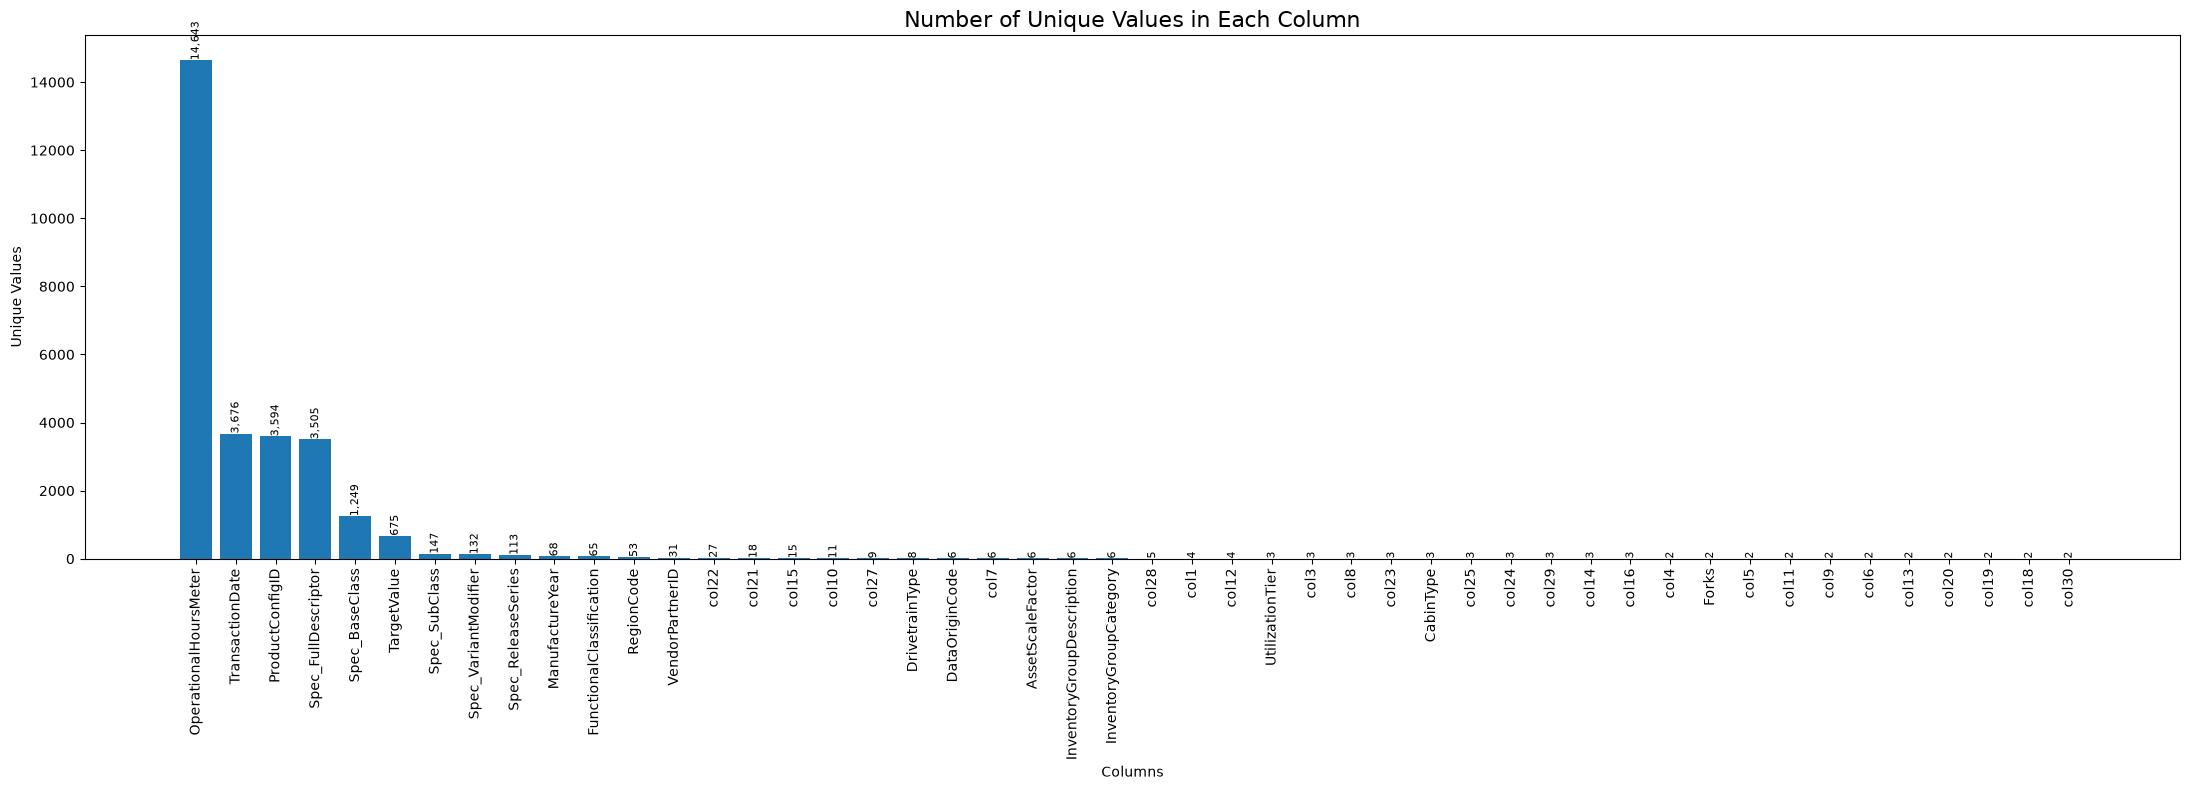

In [9]:
import matplotlib.pyplot as plt

unique_counts = trainData.nunique()

unique_counts = unique_counts.drop(["TransactionID", "AssetID"])

unique_counts = unique_counts.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(22, 8))

bars = ax.bar(unique_counts.index, unique_counts.values)

ax.set_title("Number of Unique Values in Each Column", fontsize=16)
ax.set_xlabel("Columns")
ax.set_ylabel("Unique Values")

plt.xticks(rotation=90)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:,}",
        ha="center",
        va="bottom",
        rotation=90,
        fontsize=8
    )

plt.tight_layout()
plt.show()